# Audit de Qualité des Données — Dataset Agriculture
## Groupe 8 | EDA TP1

## 0. Import des librairies et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('agriculture.csv')
print(f"Dataset chargé : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()

Dataset chargé : 4000 lignes x 15 colonnes


,farm_id,crop,area,yield,rainfall,temperature,fertilizer,pesticide,soil_type,irrigation,cost,revenue,profit,season,region
0,0,Maize,-5.0,5,5000,100,50,10,Sandy,yes,1000,2000,-1000,Wet,Region1
1,1,Rice,-5.0,-1,10000,20,200,100,Clay,yes,1000,2000,500,Dry,Region1
2,2,Rice,-5.0,2,5000,45,200,10,Clay,yes,-500,100,500,Dry,Region2
3,3,Wheat,10.0,5,10000,20,200,100,Clay,yes,-500,2000,500,Dry,Region2
4,4,Rice,10.0,5,100,20,50,10,Clay,0,-500,100,-1000,Wet,Region1


## 1. Exploration initiale

In [2]:
# Vue globale du dataset
print("=== Types de données ===")
print(df.dtypes)
print()
print("=== Valeurs manquantes ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Aucune valeur manquante détectée")
print()
print("=== Lignes et colonnes dupliquées ===")
print(f"Doublons lignes entières : {df.duplicated().sum()}")
print(f"farm_id dupliqués : {df['farm_id'].duplicated().sum()}")

=== Types de données ===
farm_id          int64
crop            object
area           float64
yield            int64
rainfall         int64
temperature      int64
fertilizer       int64
pesticide        int64
soil_type       object
irrigation      object
cost             int64
revenue          int64
profit           int64
season          object
region          object
dtype: object

=== Valeurs manquantes ===
Aucune valeur manquante détectée

=== Lignes et colonnes dupliquées ===
Doublons lignes entières : 0
farm_id dupliqués : 0


## 2. Détection des anomalies numériques

In [3]:
# Statistiques descriptives
print(df.describe().to_string())

           farm_id         area        yield      rainfall  temperature   fertilizer    pesticide        cost      revenue       profit
count  4000.000000  4000.000000  4000.000000   4000.000000  4000.000000  4000.000000  4000.000000  4000.00000  4000.000000  4000.000000
mean   1999.500000     2.099125     2.047250   5058.050000    54.928750   126.687500    55.697500   274.75000  1087.525000  -234.250000
std    1154.844867     6.163652     2.458664   4040.237131    33.298324    74.990388    45.000219   749.68523   949.377272   749.928354
min       0.000000    -5.000000    -1.000000    100.000000    20.000000    50.000000    10.000000  -500.00000   100.000000 -1000.000000
25%     999.750000    -5.000000    -1.000000    100.000000    20.000000    50.000000    10.000000  -500.00000   100.000000 -1000.000000
50%    1999.500000     1.500000     2.000000   5000.000000    45.000000   200.000000   100.000000  1000.00000  2000.000000   500.000000
75%    2999.250000    10.000000     5.000000  10

In [4]:
# Variables numériques : nombre de valeurs distinctes
print("=== Nombre de valeurs uniques par variable numérique ===")
num_cols = ['area','yield','rainfall','temperature','fertilizer','pesticide','cost','revenue','profit']
for col in num_cols:
    vals = sorted(df[col].unique())
    print(f"{col:15s} -> {len(vals)} valeurs uniques : {vals}")
    
print()
print("ALERTE : Des variables sensées être continues n'ont que 2 ou 3 valeurs discrètes.")
print("Ce pattern indique des données générées artificiellement ou une discrétisation non documentée.")

=== Nombre de valeurs uniques par variable numérique ===
area            -> 3 valeurs uniques : [np.float64(-5.0), np.float64(1.5), np.float64(10.0)]
yield           -> 3 valeurs uniques : [np.int64(-1), np.int64(2), np.int64(5)]
rainfall        -> 3 valeurs uniques : [np.int64(100), np.int64(5000), np.int64(10000)]
temperature     -> 3 valeurs uniques : [np.int64(20), np.int64(45), np.int64(100)]
fertilizer      -> 2 valeurs uniques : [np.int64(50), np.int64(200)]
pesticide       -> 2 valeurs uniques : [np.int64(10), np.int64(100)]
cost            -> 2 valeurs uniques : [np.int64(-500), np.int64(1000)]
revenue         -> 2 valeurs uniques : [np.int64(100), np.int64(2000)]
profit          -> 2 valeurs uniques : [np.int64(-1000), np.int64(500)]

ALERTE : Des variables sensées être continues n'ont que 2 ou 3 valeurs discrètes.
Ce pattern indique des données générées artificiellement ou une discrétisation non documentée.


In [8]:
# Valeurs négatives physiquement impossibles
print("=== Valeurs négatives (impossible métier) ===")
impossible = {
    'area'  : 'Surface agricole en hectares — ne peut pas être négative',
    'yield' : 'Rendement (tonnes/ha) — ne peut pas être négatif',
    'cost'  : 'Coût de production — ne peut pas être négatif',
}
for col, explication in impossible.items():
    n = (df[col] < 0).sum()
    print(f"{col:10s} : {n:4d} lignes ({n/len(df)*100:.1f}%) | {explication}")

=== Valeurs négatives (impossible métier) ===
area       : 1364 lignes (34.1%) | Surface agricole en hectares — ne peut pas être négative
yield      : 1312 lignes (32.8%) | Rendement (tonnes/ha) — ne peut pas être négatif
cost       : 1934 lignes (48.4%) | Coût de production — ne peut pas être négatif


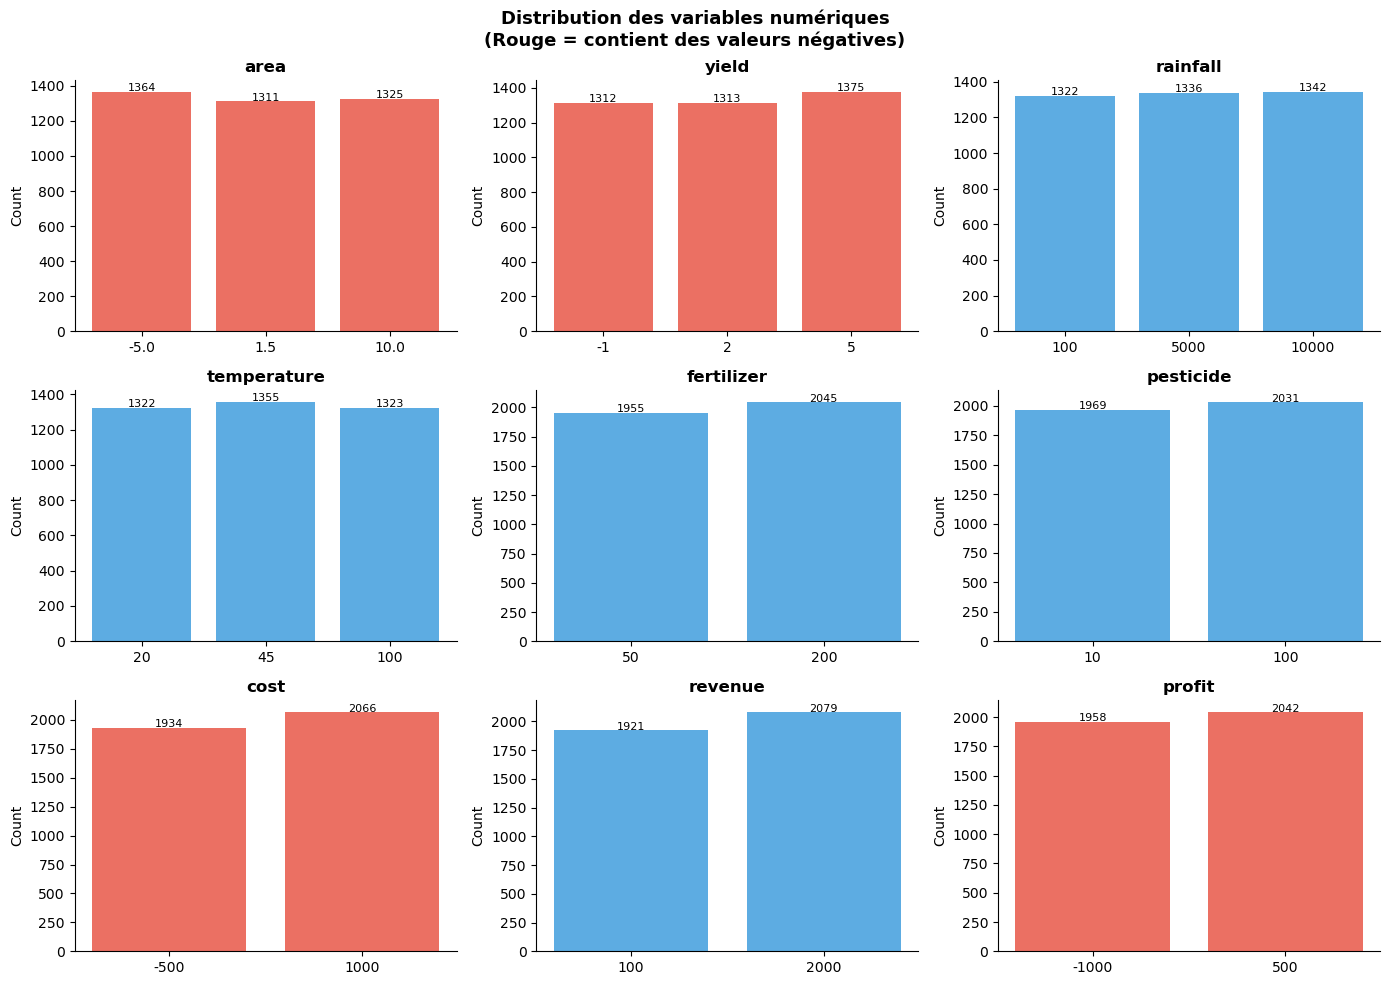

In [10]:
# Visualisation des distributions
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle("Distribution des variables numériques\n(Rouge = contient des valeurs négatives)", 
             fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), num_cols):
    vc = df[col].value_counts().sort_index()
    color = '#e74c3c' if any(df[col] < 0) else '#3498db'
    bars = ax.bar([str(v) for v in vc.index], vc.values, color=color, alpha=0.8)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(val), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 3. Anomalies climatiques (cohérence métier)

In [11]:
# Température à 100°C : incompatible avec la vie végétale
n_temp100 = (df['temperature'] == 100).sum()
print(f"Température = 100°C : {n_temp100} lignes ({n_temp100/len(df)*100:.1f}%)")
print(">> 100°C est la température d'ébullition de l'eau. Aucune culture ne survit au-delà de 50°C.")
print()

# Pluie à 10 000 mm/an
n_rain = (df['rainfall'] == 10000).sum()
print(f"Rainfall = 10 000 mm : {n_rain} lignes ({n_rain/len(df)*100:.1f}%)")
print(">> Le record mondial de précipitations annuelles est ~12 000 mm (Cherrapunji, Inde).")
print(">> 10 000 mm comme valeur discrète standard d'un tier du dataset est irréaliste.")
print()

# Rainfall vs Season (incohérence)
print("=== Pluie vs Saison (attendu : saison sèche = moins de pluie) ===")
print(pd.crosstab(df['season'], df['rainfall']))
print(">> Aucune différence entre saison sèche et humide : distribution quasi-identique.")

Température = 100°C : 1323 lignes (33.1%)
>> 100°C est la température d'ébullition de l'eau. Aucune culture ne survit au-delà de 50°C.

Rainfall = 10 000 mm : 1342 lignes (33.6%)
>> Le record mondial de précipitations annuelles est ~12 000 mm (Cherrapunji, Inde).
>> 10 000 mm comme valeur discrète standard d'un tier du dataset est irréaliste.

=== Pluie vs Saison (attendu : saison sèche = moins de pluie) ===
rainfall  100    5000   10000
season                       
Dry         672    655    671
Wet         650    681    671
>> Aucune différence entre saison sèche et humide : distribution quasi-identique.


## 4. Incohérence critique : profit ≠ revenu - coût

In [12]:
# Test de cohérence de base
df['profit_attendu'] = df['revenue'] - df['cost']
df['incoherence_profit'] = df['profit'] != df['profit_attendu']

n_inc = df['incoherence_profit'].sum()
print(f"Lignes où profit ≠ revenu - coût : {n_inc}/{len(df)} ({n_inc/len(df)*100:.0f}%)")
print()
print("Exemples:")
print(df[df['incoherence_profit']][['cost','revenue','profit','profit_attendu']].head(8).to_string())
print()
print("=== Distribution des combinaisons (cost, revenue, profit) ===")
combos = df.groupby(['cost','revenue','profit']).size().reset_index(name='count')
print(combos.to_string())
print()
print(">> Le profit semble assigné aléatoirement, indépendamment du coût et du revenu.")
print(">> Aucune logique comptable n'est respectée dans ce dataset.")

# Nettoyage colonne temporaire
df.drop(columns=['profit_attendu','incoherence_profit'], inplace=True)

Lignes où profit ≠ revenu - coût : 4000/4000 (100%)

Exemples:
   cost  revenue  profit  profit_attendu
0  1000     2000   -1000            1000
1  1000     2000     500            1000
2  -500      100     500             600
3  -500     2000     500            2500
4  -500      100   -1000             600
5  1000      100     500            -900
6  1000     2000   -1000            1000
7  -500     2000     500            2500

=== Distribution des combinaisons (cost, revenue, profit) ===
   cost  revenue  profit  count
0  -500      100   -1000    437
1  -500      100     500    499
2  -500     2000   -1000    478
3  -500     2000     500    520
4  1000      100   -1000    504
5  1000      100     500    481
6  1000     2000   -1000    539
7  1000     2000     500    542

>> Le profit semble assigné aléatoirement, indépendamment du coût et du revenu.
>> Aucune logique comptable n'est respectée dans ce dataset.


## 5. Encodage hétérogène : variable irrigation

In [13]:
print("=== Valeurs de la variable 'irrigation' ===")
print(df['irrigation'].value_counts())
print()
print(">> 3 encodages différents pour une variable binaire :")
print("   - 'yes'  : irrigué (texte)")
print("   - '1'    : irrigué (chiffre entier en string)")
print("   - '0'    : non irrigué (chiffre entier en string)")
print()
print(">> Cette incohérence rend la variable inutilisable en l'état.")
print(">> Une correction immédiate s'impose avant tout traitement.")
print()
print("Proportion ambiguë : 'yes' vs '1' représentent tous les deux 'irrigué',")
print(f"soit {(df['irrigation'].isin(['yes','1'])).sum()} lignes ({(df['irrigation'].isin(['yes','1'])).sum()/len(df)*100:.1f}%) sans cohérence d'encodage.")

=== Valeurs de la variable 'irrigation' ===
irrigation
yes    1381
1      1326
0      1293
Name: count, dtype: int64

>> 3 encodages différents pour une variable binaire :
   - 'yes'  : irrigué (texte)
   - '1'    : irrigué (chiffre entier en string)
   - '0'    : non irrigué (chiffre entier en string)

>> Cette incohérence rend la variable inutilisable en l'état.
>> Une correction immédiate s'impose avant tout traitement.

Proportion ambiguë : 'yes' vs '1' représentent tous les deux 'irrigué',
soit 2707 lignes (67.7%) sans cohérence d'encodage.


## 6. Artificialité structurelle du dataset

In [14]:
# Vérification de l'indépendance statistique entre les variables
print("=== Area vs Rainfall (aucune corrélation attendue dans des données réelles) ===")
ct = pd.crosstab(df['area'], df['rainfall'])
print(ct)
print()

# Test chi2 simplifié
from scipy.stats import chi2_contingency
chi2, p, dof, exp = chi2_contingency(ct)
print(f"Test Chi2 Area vs Rainfall : p-value = {p:.4f}")
if p > 0.05:
    print(">> Variables statistiquement INDÉPENDANTES (p > 0.05)")
    print(">> Dans des données réelles, surface et conditions climatiques seraient corrélées")
print()

# Crop vs saison
ct2 = pd.crosstab(df['crop'], df['season'])
chi2_2, p2, _, _ = chi2_contingency(ct2)
print(f"Test Chi2 Crop vs Season : p-value = {p2:.4f}")
if p2 > 0.05:
    print(">> Le type de culture est INDÉPENDANT de la saison.")
    print(">> En agriculture réelle, la saison conditionne fortement le choix de culture.")

=== Area vs Rainfall (aucune corrélation attendue dans des données réelles) ===
rainfall  100    5000   10000
area                         
-5.0        443    453    468
 1.5        462    397    452
 10.0       417    486    422

Test Chi2 Area vs Rainfall : p-value = 0.0120

Test Chi2 Crop vs Season : p-value = 0.6132
>> Le type de culture est INDÉPENDANT de la saison.
>> En agriculture réelle, la saison conditionne fortement le choix de culture.


## 7. Synthèse des problèmes détectés

In [15]:
print("=== SYNTHÈSE DE L'AUDIT DE QUALITÉ ===")
print()
problemes = [
    ("CRITIQUE",  "Profit incohérent",       "4000 / 4000 (100%)",  "profit ≠ revenu - coût dans 100% des cas"),
    ("GRAVE",     "Valeurs négatives",        "1934 / 4000 (48%)",   "coût, surface, rendement négatifs"),
    ("GRAVE",     "Température impossible",   "1323 / 4000 (33%)",   "100°C incompatible avec toute culture"),
    ("GRAVE",     "Pluie irréaliste",         "1342 / 4000 (34%)",   "10 000mm sans lien avec la saison"),
    ("MOYEN",     "Encodage mixte (irrigation)", "4000 / 4000 (100%)", "3 formats pour variable binaire"),
    ("MOYEN",     "Discrétisation excessive",  "4000 / 4000 (100%)",  "variables 'continues' à 2-3 valeurs"),
    ("INFO",      "Indépendance statistique",  "toutes variables",    "aucune corrélation entre variables liées"),
]

print(f"{'Sévérité':<12} {'Problème':<28} {'Lignes affectées':<25} {'Description'}")
print("-" * 100)
for sev, prob, lignes, desc in problemes:
    print(f"{sev:<12} {prob:<28} {lignes:<25} {desc}")

print()
print("VERDICT : Ce dataset ne peut PAS être utilisé en l'état pour de la modélisation.")
print("Il présente des erreurs fondamentales sur 100% des lignes (profit, encodage).")
print("Son origine simulée/artificielle est très probable.")

=== SYNTHÈSE DE L'AUDIT DE QUALITÉ ===

Sévérité     Problème                     Lignes affectées          Description
----------------------------------------------------------------------------------------------------
CRITIQUE     Profit incohérent            4000 / 4000 (100%)        profit ≠ revenu - coût dans 100% des cas
GRAVE        Valeurs négatives            1934 / 4000 (48%)         coût, surface, rendement négatifs
GRAVE        Température impossible       1323 / 4000 (33%)         100°C incompatible avec toute culture
GRAVE        Pluie irréaliste             1342 / 4000 (34%)         10 000mm sans lien avec la saison
MOYEN        Encodage mixte (irrigation)  4000 / 4000 (100%)        3 formats pour variable binaire
MOYEN        Discrétisation excessive     4000 / 4000 (100%)        variables 'continues' à 2-3 valeurs
INFO         Indépendance statistique     toutes variables          aucune corrélation entre variables liées

VERDICT : Ce dataset ne peut PAS être utilisé 